# Problem 3

## Step 0: Environment and Data Setup

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time
import matplotlib.pyplot as plt
from torchinfo import summary

# 1. Device Setup (Hooking up your RTX 4060)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

# 2. Dataset Setup (Consistent 40k/10k Split)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_dataset, val_dataset = random_split(full_train_dataset, [40000, 10000], generator=torch.Generator().manual_seed(42))
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Environment and DataLoaders ready for ResNet!")

Using device: cuda
NVIDIA GeForce RTX 4060 Laptop GPU
Files already downloaded and verified
Files already downloaded and verified
Environment and DataLoaders ready for ResNet!


## Step 1: Define ResNet-11 and ResNet-18 Architectures

In [2]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, 
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, 
                          stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)  # SKIP CONNECTION
        out = F.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10, dropout_rate=0.0):
        super(ResNet, self).__init__()
        self.in_channels = 64
        self.dropout_rate = dropout_rate

        # CIFAR-10 Adaptation: single 3x3 conv, no max pooling
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        
        self.linear = nn.Linear(512 * block.expansion, num_classes)
        self.dropout = nn.Dropout(self.dropout_rate)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = out.view(out.size(0), -1)
        
        if self.dropout_rate > 0:
            out = self.dropout(out)
            
        out = self.linear(out)
        return out

# Model Builders
def ResNet11(dropout_rate=0.0):
    """Custom baseline with 1 block per stage (~11 layers)"""
    return ResNet(BasicBlock, [1, 1, 1, 1], dropout_rate=dropout_rate)

def ResNet18(dropout_rate=0.0):
    """Standard ResNet-18 with 2 blocks per stage"""
    return ResNet(BasicBlock, [2, 2, 2, 2], dropout_rate=dropout_rate)

# Verify the architectures
resnet11_baseline = ResNet11().to(device)
resnet18_baseline = ResNet18().to(device)

print("ResNet-11 Parameters:")
print(summary(resnet11_baseline, input_size=(64, 3, 32, 32)))
print("\nResNet-18 Parameters:")
print(summary(resnet18_baseline, input_size=(64, 3, 32, 32)))

ResNet-11 Parameters:
Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [64, 10]                  --
├─Conv2d: 1-1                            [64, 64, 32, 32]          1,728
├─BatchNorm2d: 1-2                       [64, 64, 32, 32]          128
├─Sequential: 1-3                        [64, 64, 32, 32]          --
│    └─BasicBlock: 2-1                   [64, 64, 32, 32]          --
│    │    └─Conv2d: 3-1                  [64, 64, 32, 32]          36,864
│    │    └─BatchNorm2d: 3-2             [64, 64, 32, 32]          128
│    │    └─Conv2d: 3-3                  [64, 64, 32, 32]          36,864
│    │    └─BatchNorm2d: 3-4             [64, 64, 32, 32]          128
│    │    └─Sequential: 3-5              [64, 64, 32, 32]          --
├─Sequential: 1-4                        [64, 128, 16, 16]         --
│    └─BasicBlock: 2-2                   [64, 128, 16, 16]         --
│    │    └─Conv2d: 3-6                  [64, 128

## Step 2: Training ResNet-11 and ResNet-18 (Part A)

In [4]:
import time
import torch.nn as nn
import torch.optim as optim

epochs = 50
criterion = nn.CrossEntropyLoss()

# =====================================================================
# 1. TRAIN RESNET-11 BASELINE
# =====================================================================
resnet11 = ResNet11(dropout_rate=0.0).to(device)
optimizer11 = optim.SGD(resnet11.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler11 = optim.lr_scheduler.StepLR(optimizer11, step_size=15, gamma=0.5)

r11_train_loss, r11_train_acc = [], []
r11_val_loss, r11_val_acc = [], []

print("Starting ResNet-11 Training (50 Epochs)...")
start_time_11 = time.time()

for epoch in range(epochs):
    resnet11.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer11.zero_grad()
        outputs = resnet11(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer11.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    r11_train_loss.append(running_loss / len(train_loader.dataset))
    r11_train_acc.append((correct / total) * 100)
    
    # Validation
    resnet11.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet11(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    r11_val_loss.append(val_loss / len(val_loader.dataset))
    r11_val_acc.append((val_correct / val_total) * 100)
    scheduler11.step()
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {r11_train_acc[-1]:.2f}% | Val Acc: {r11_val_acc[-1]:.2f}%")

total_time_11 = time.time() - start_time_11
print(f"ResNet-11 Training Complete in {total_time_11:.2f} seconds!\n")


# =====================================================================
# 2. TRAIN RESNET-18 BASELINE
# =====================================================================
resnet18 = ResNet18(dropout_rate=0.0).to(device)
optimizer18 = optim.SGD(resnet18.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler18 = optim.lr_scheduler.StepLR(optimizer18, step_size=15, gamma=0.5)

r18_train_loss, r18_train_acc = [], []
r18_val_loss, r18_val_acc = [], []

print("Starting ResNet-18 Training (50 Epochs)...")
start_time_18 = time.time()

for epoch in range(epochs):
    resnet18.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer18.zero_grad()
        outputs = resnet18(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer18.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    r18_train_loss.append(running_loss / len(train_loader.dataset))
    r18_train_acc.append((correct / total) * 100)
    
    # Validation
    resnet18.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet18(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    r18_val_loss.append(val_loss / len(val_loader.dataset))
    r18_val_acc.append((val_correct / val_total) * 100)
    scheduler18.step()
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {r18_train_acc[-1]:.2f}% | Val Acc: {r18_val_acc[-1]:.2f}%")

total_time_18 = time.time() - start_time_18
print(f"ResNet-18 Training Complete in {total_time_18:.2f} seconds!")

Starting ResNet-11 Training (50 Epochs)...
Epoch [1/50] | Train Acc: 51.39% | Val Acc: 60.28%
Epoch [5/50] | Train Acc: 86.34% | Val Acc: 76.93%
Epoch [10/50] | Train Acc: 98.00% | Val Acc: 74.66%
Epoch [15/50] | Train Acc: 99.92% | Val Acc: 82.49%
Epoch [20/50] | Train Acc: 100.00% | Val Acc: 83.59%
Epoch [25/50] | Train Acc: 100.00% | Val Acc: 83.77%
Epoch [30/50] | Train Acc: 100.00% | Val Acc: 83.46%
Epoch [35/50] | Train Acc: 100.00% | Val Acc: 83.47%
Epoch [40/50] | Train Acc: 100.00% | Val Acc: 83.51%
Epoch [45/50] | Train Acc: 100.00% | Val Acc: 83.57%
Epoch [50/50] | Train Acc: 100.00% | Val Acc: 83.60%
ResNet-11 Training Complete in 928.15 seconds!

Starting ResNet-18 Training (50 Epochs)...
Epoch [1/50] | Train Acc: 50.71% | Val Acc: 61.44%
Epoch [5/50] | Train Acc: 87.84% | Val Acc: 77.46%
Epoch [10/50] | Train Acc: 97.16% | Val Acc: 80.01%
Epoch [15/50] | Train Acc: 99.12% | Val Acc: 82.41%
Epoch [20/50] | Train Acc: 100.00% | Val Acc: 85.40%
Epoch [25/50] | Train Acc: 100

## Step 3: Plot the Baseline Part A Curves

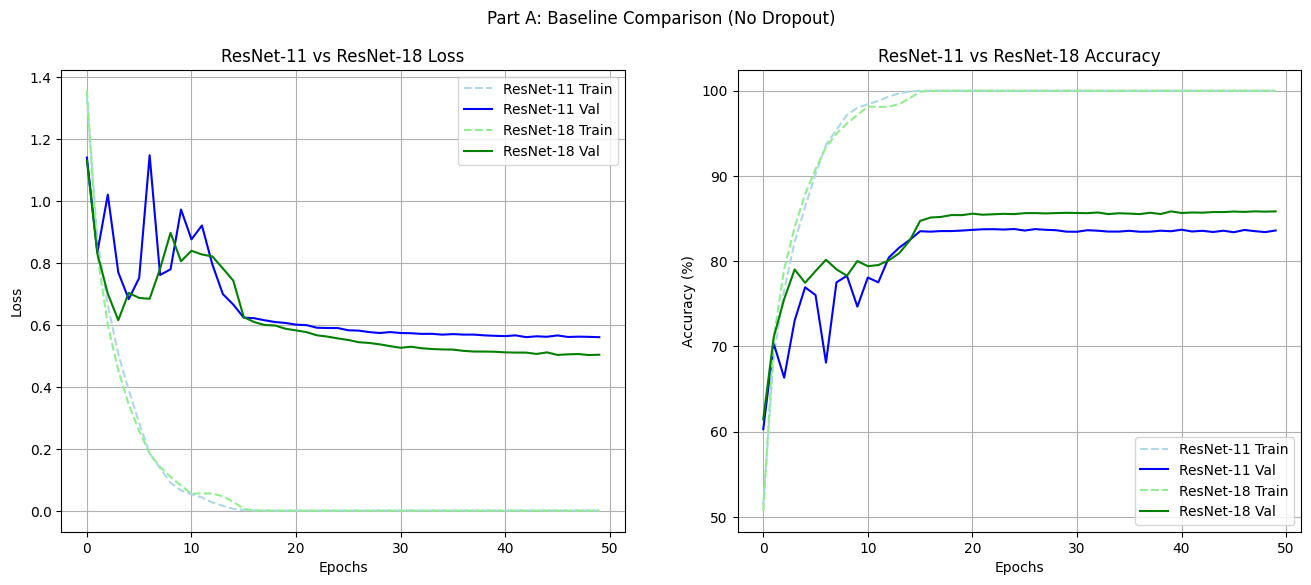

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Loss Plot
ax1.plot(r11_train_loss, label='ResNet-11 Train', color='lightblue', linestyle='--')
ax1.plot(r11_val_loss, label='ResNet-11 Val', color='blue')
ax1.plot(r18_train_loss, label='ResNet-18 Train', color='lightgreen', linestyle='--')
ax1.plot(r18_val_loss, label='ResNet-18 Val', color='green')
ax1.set_title('ResNet-11 vs ResNet-18 Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy Plot
ax2.plot(r11_train_acc, label='ResNet-11 Train', color='lightblue', linestyle='--')
ax2.plot(r11_val_acc, label='ResNet-11 Val', color='blue')
ax2.plot(r18_train_acc, label='ResNet-18 Train', color='lightgreen', linestyle='--')
ax2.plot(r18_val_acc, label='ResNet-18 Val', color='green')
ax2.set_title('ResNet-11 vs ResNet-18 Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Part A: Baseline Comparison (No Dropout)')
plt.show()

## Step 4: Final Test Evaluation & Confusion Matrix (Part A)

Final ResNet-11 Baseline Test Accuracy: 83.14%
Final ResNet-18 Baseline Test Accuracy: 84.75%


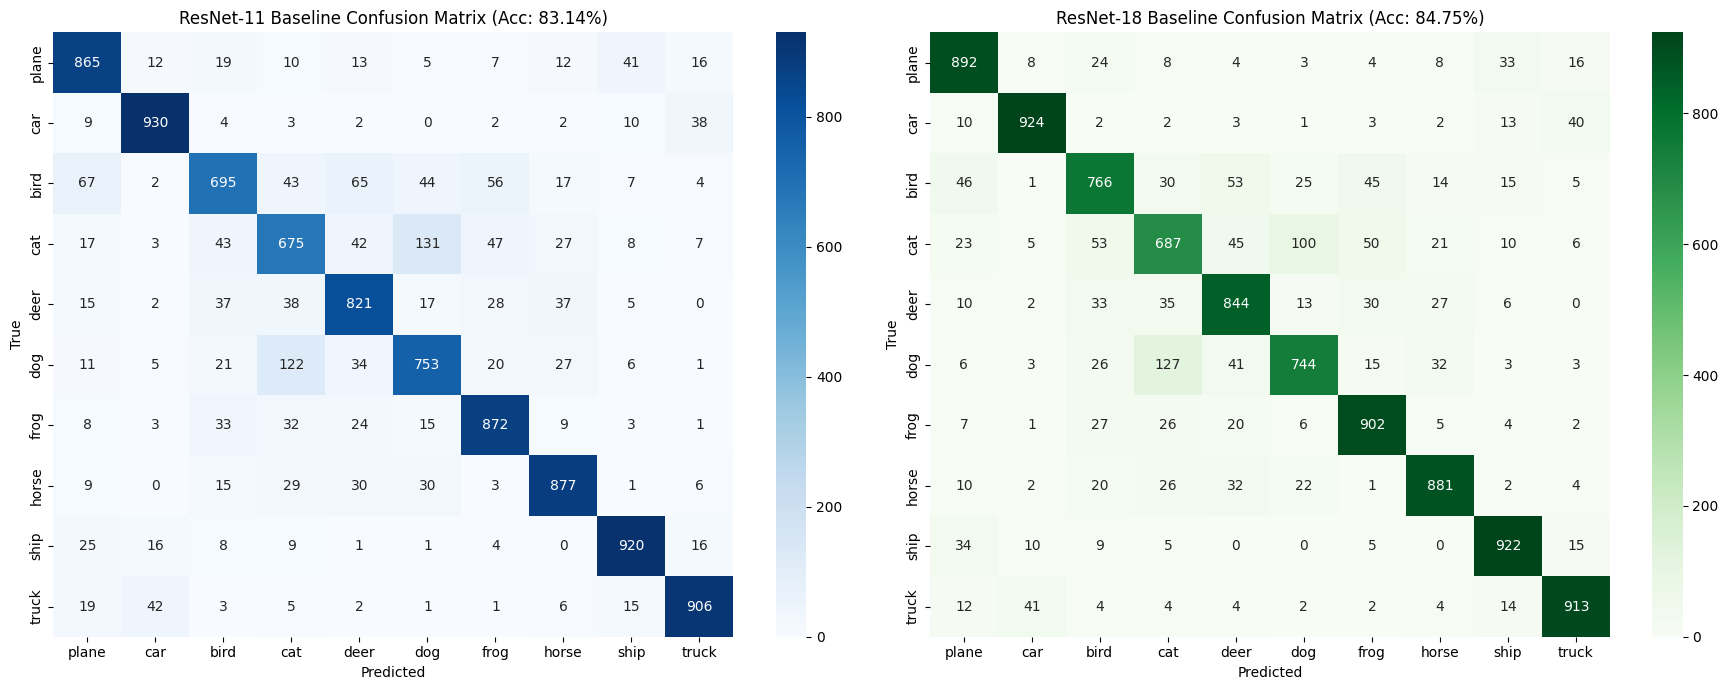

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

def evaluate_and_get_cm(model, loader, name):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    acc = (correct / total) * 100
    print(f"Final {name} Test Accuracy: {acc:.2f}%")
    return acc, confusion_matrix(all_labels, all_preds)

# Evaluate both models
acc_11, cm_11 = evaluate_and_get_cm(resnet11, test_loader, "ResNet-11 Baseline")
acc_18, cm_18 = evaluate_and_get_cm(resnet18, test_loader, "ResNet-18 Baseline")

# Plot Confusion Matrices Side-by-Side
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_11, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax1)
ax1.set_title(f'ResNet-11 Baseline Confusion Matrix (Acc: {acc_11:.2f}%)')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')

sns.heatmap(cm_18, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes, ax=ax2)
ax2.set_title(f'ResNet-18 Baseline Confusion Matrix (Acc: {acc_18:.2f}%)')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

plt.tight_layout()
plt.show()

# Part B: Dropout in ResNets

## Step 5: Train the Dropout Variants (Part B)

In [9]:
# Dictionaries to hold our results
dropout_results = {}
configs = [
    {"name": "ResNet-11_p3", "model_fn": lambda: ResNet11(dropout_rate=0.3)},
    {"name": "ResNet-11_p5", "model_fn": lambda: ResNet11(dropout_rate=0.5)},
    {"name": "ResNet-18_p3", "model_fn": lambda: ResNet18(dropout_rate=0.3)},
    {"name": "ResNet-18_p5", "model_fn": lambda: ResNet18(dropout_rate=0.5)},
]

for config in configs:
    name = config["name"]
    print(f"\n=========================================\nTraining {name}...")
    
    model = config["model_fn"]().to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
    
    train_accs, val_accs = [], []
    
    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        train_accs.append((correct / total) * 100)
        
        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                
        val_accs.append((val_correct / val_total) * 100)
        scheduler.step()
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {train_accs[-1]:.2f}% | Val Acc: {val_accs[-1]:.2f}%")
            
    # Final Test Evaluation
    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            
    final_test_acc = (test_correct / test_total) * 100
    print(f"-> {name} Final Test Accuracy: {final_test_acc:.2f}%")
    
    # Save statistics for later analysis
    dropout_results[name] = {
        "train_acc": train_accs,
        "val_acc": val_accs,
        "test_acc": final_test_acc
    }


Training ResNet-11_p3...
Epoch [1/50] | Train Acc: 48.82% | Val Acc: 59.29%
Epoch [10/50] | Train Acc: 95.94% | Val Acc: 78.81%
Epoch [20/50] | Train Acc: 100.00% | Val Acc: 83.49%
Epoch [30/50] | Train Acc: 100.00% | Val Acc: 83.49%
Epoch [40/50] | Train Acc: 100.00% | Val Acc: 83.43%
Epoch [50/50] | Train Acc: 100.00% | Val Acc: 83.37%
-> ResNet-11_p3 Final Test Accuracy: 83.34%

Training ResNet-11_p5...
Epoch [1/50] | Train Acc: 46.33% | Val Acc: 50.73%
Epoch [10/50] | Train Acc: 94.69% | Val Acc: 76.75%
Epoch [20/50] | Train Acc: 99.99% | Val Acc: 83.31%
Epoch [30/50] | Train Acc: 100.00% | Val Acc: 83.59%
Epoch [40/50] | Train Acc: 100.00% | Val Acc: 83.47%
Epoch [50/50] | Train Acc: 100.00% | Val Acc: 83.73%
-> ResNet-11_p5 Final Test Accuracy: 83.14%

Training ResNet-18_p3...
Epoch [1/50] | Train Acc: 49.01% | Val Acc: 55.16%
Epoch [10/50] | Train Acc: 96.38% | Val Acc: 81.60%
Epoch [20/50] | Train Acc: 100.00% | Val Acc: 85.90%
Epoch [30/50] | Train Acc: 100.00% | Val Acc: 86.

## Step 6: The Cross-Architecture Comparison

=================== CROSS-MODEL COMPARISON TABLE ===================
    Model Family  Parameters (M)  Training Time (s)  Final Test Accuracy (%)
  AlexNet (Best)            7.45         677.000000                    88.38
VGGNet-11 (Best)            9.75         428.900000                    77.05
ResNet-11 (Best)            4.95         928.151606                    83.34
ResNet-18 (Best)           11.17        1571.271165                    85.95



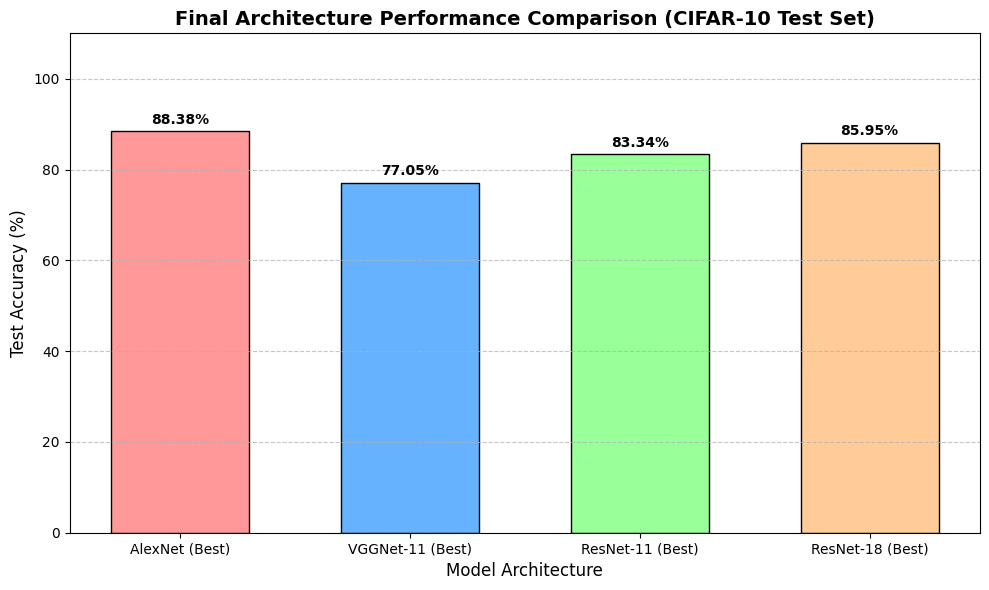

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# I'LL USE MY PREVIOUS RESULTS HERE
# =====================================================================
alexnet_test_acc = 88.38  # Replace with your best AlexNet test accuracy %
alexnet_train_time = 677  # Replace with your AlexNet training time in seconds
alexnet_params = 7.45     # In Millions

vgg11_test_acc = 77.05    # Your VGG-11 baseline test accuracy %
vgg11_train_time = 428.9    # Replace with your VGG training time in seconds
vgg11_params = 9.75       # In Millions

# =====================================================================
# AUTOMATICALLY GRAB RESNET RESULTS (Assuming Step 5 finished)
# =====================================================================
# We pull the best performing dropout or baseline configurations
r11_best_acc = max(acc_11, dropout_results["ResNet-11_p3"]["test_acc"], dropout_results["ResNet-11_p5"]["test_acc"])
r18_best_acc = max(acc_18, dropout_results["ResNet-18_p3"]["test_acc"], dropout_results["ResNet-18_p5"]["test_acc"])

# Let's create the comparison dataset
data = {
    "Model Family": ["AlexNet (Best)", "VGGNet-11 (Best)", "ResNet-11 (Best)", "ResNet-18 (Best)"],
    "Parameters (M)": [alexnet_params, vgg11_params, 4.95, 11.17],
    "Training Time (s)": [alexnet_train_time, vgg11_train_time, total_time_11, total_time_18],
    "Final Test Accuracy (%)": [alexnet_test_acc, vgg11_test_acc, r11_best_acc, r18_best_acc]
}

df = pd.DataFrame(data)
print("=================== CROSS-MODEL COMPARISON TABLE ===================")
print(df.to_string(index=False))
print("====================================================================\n")

# Plot the Final Bar Chart required by the prompt
plt.figure(figsize=(10, 6))
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
bars = plt.bar(df["Model Family"], df["Final Test Accuracy (%)"], color=colors, edgecolor='black', width=0.6)

# We add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.title("Final Architecture Performance Comparison (CIFAR-10 Test Set)", fontsize=14, fontweight='bold')
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.xlabel("Model Architecture", fontsize=12)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()